# Sinais de Banda Básica e Banda Passante
## Seção 3.10 — Curso de Princípios de Comunicação — UnB

**Objetivo:** Visualizar passo a passo a representação de sinais passantes em banda básica:  
sinal analítico, Transformada de Hilbert, componentes I/Q, envelope e fase instantânea.

---
| Seção | Conteúdo |
|---|---|
| 1 | Banda básica vs. banda passante — comparação de espectros |
| 2 | Passo a passo: construção do sinal analítico |
| 3 | Transformada de Hilbert — visualização |
| 4 | Envelope complexo e componentes I/Q |
| 5 | Trajetória I/Q no plano complexo (constelação) |
| 6 | Envelope e fase instantânea |
| 7 | Modulador/demodulador I/Q completo |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import fft, ifft, fftfreq, fftshift, fftshift
from scipy import signal as sig

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

def hilbert_scipy(x):
    """Transformada de Hilbert via scipy."""
    return sig.hilbert(x)

def espectro(x, fs, N_fft=None):
    """Retorna (f, X) com espectro bilateral centrado em 0."""
    N = len(x) if N_fft is None else N_fft
    X = fftshift(fft(x, n=N)) / fs
    f = fftshift(fftfreq(N, 1/fs))
    return f, X

print('Pacotes carregados.')

Pacotes carregados.


---
## 1. Banda Básica vs. Banda Passante

- **Banda básica**: espectro concentrado em torno de $f = 0$, largura $W$
- **Banda passante**: espectro concentrado em torno de $\pm f_c$ (portadora), $f_c \gg W$

O sinal passante é obtido **modulando** o sinal de banda básica em uma portadora.

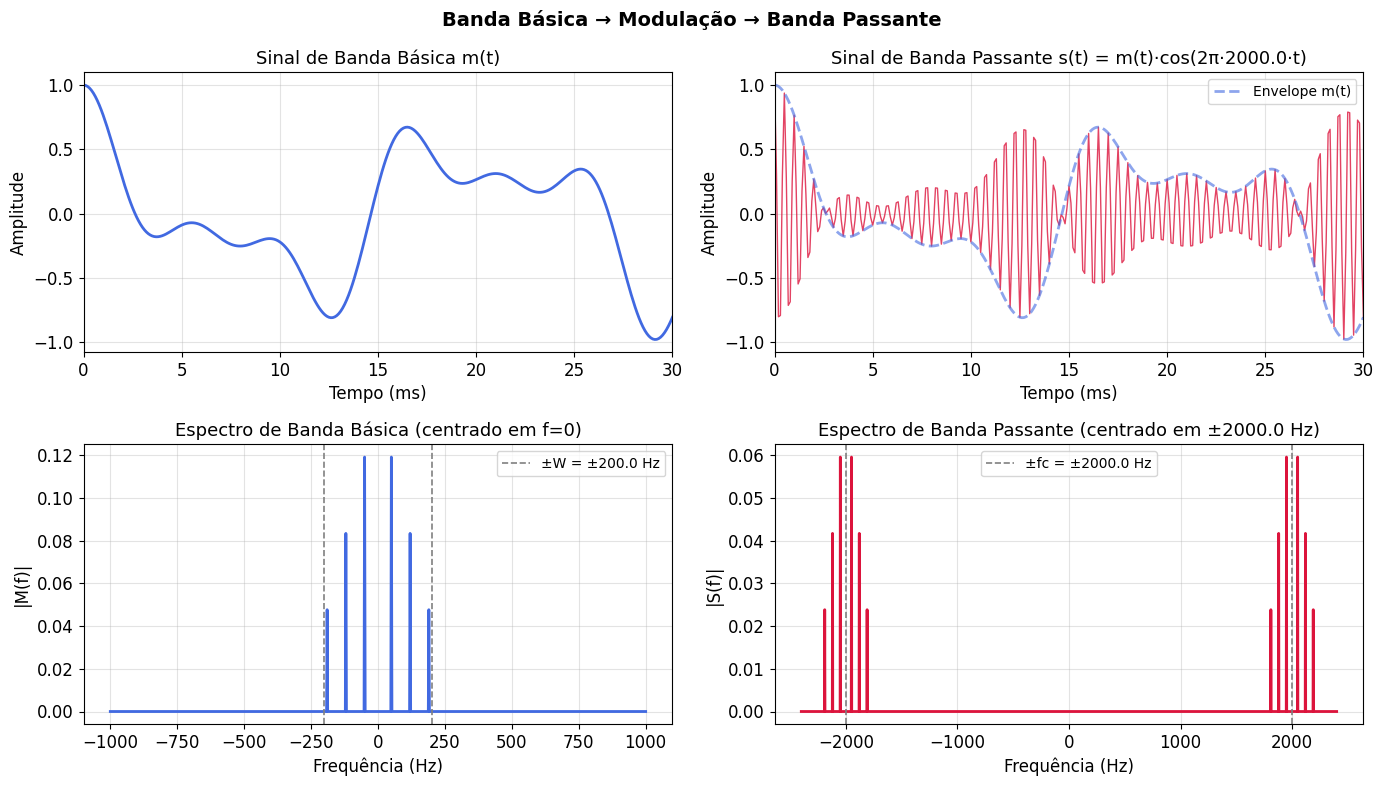

In [2]:
fs  = 10000
T   = 0.5
t   = np.arange(0, T, 1/fs)
N   = len(t)

W   = 200.0   # largura de banda do sinal de mensagem (Hz)
fc  = 2000.0  # frequência portadora (Hz)

# Sinal de mensagem (banda básica) — soma de 3 senóides lentas
m_t = (np.cos(2*np.pi*50*t) +
       0.7*np.cos(2*np.pi*120*t) +
       0.4*np.cos(2*np.pi*190*t))
m_t /= m_t.max()  # normalizar

# Sinal passante (AM-DSB-SC)
s_t = m_t * np.cos(2*np.pi*fc*t)

f_m, M = espectro(m_t, fs)
f_s, S = espectro(s_t, fs)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Tempo — mensagem
axes[0,0].plot(t*1000, m_t, 'royalblue', lw=2)
axes[0,0].set_xlabel('Tempo (ms)')
axes[0,0].set_ylabel('Amplitude')
axes[0,0].set_title('Sinal de Banda Básica m(t)')
axes[0,0].set_xlim([0, 30])

# Espectro — mensagem
mask = np.abs(f_m) <= 5*W
axes[1,0].fill_between(f_m[mask], np.abs(M[mask]), alpha=0.3, color='royalblue')
axes[1,0].plot(f_m[mask], np.abs(M[mask]), 'royalblue', lw=2)
axes[1,0].axvline(-W, color='gray', ls='--', lw=1.2, label=f'±W = ±{W} Hz')
axes[1,0].axvline( W, color='gray', ls='--', lw=1.2)
axes[1,0].set_xlabel('Frequência (Hz)')
axes[1,0].set_ylabel('|M(f)|')
axes[1,0].set_title(f'Espectro de Banda Básica (centrado em f=0)')
axes[1,0].legend(fontsize=10)

# Tempo — passante
axes[0,1].plot(t*1000, s_t, 'crimson', lw=1, alpha=0.8)
axes[0,1].plot(t*1000, m_t, 'royalblue', lw=2, alpha=0.6, ls='--', label='Envelope m(t)')
axes[0,1].set_xlabel('Tempo (ms)')
axes[0,1].set_ylabel('Amplitude')
axes[0,1].set_title(f'Sinal de Banda Passante s(t) = m(t)·cos(2π·{fc}·t)')
axes[0,1].set_xlim([0, 30])
axes[0,1].legend(fontsize=10)

# Espectro — passante
mask2 = (np.abs(f_s) >= fc - 2*W) & (np.abs(f_s) <= fc + 2*W)
axes[1,1].fill_between(f_s[mask2], np.abs(S[mask2]), alpha=0.3, color='crimson')
axes[1,1].plot(f_s[mask2], np.abs(S[mask2]), 'crimson', lw=2)
axes[1,1].axvline(-fc, color='gray', ls='--', lw=1.2, label=f'±fc = ±{fc} Hz')
axes[1,1].axvline( fc, color='gray', ls='--', lw=1.2)
axes[1,1].set_xlabel('Frequência (Hz)')
axes[1,1].set_ylabel('|S(f)|')
axes[1,1].set_title(f'Espectro de Banda Passante (centrado em ±{fc} Hz)')
axes[1,1].legend(fontsize=10)

fig.suptitle('Banda Básica → Modulação → Banda Passante', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Passo a Passo: Construção do Sinal Analítico

Para ir de um sinal passante **real** $s(t)$ para a representação em banda básica:

1. **Passo 1**: Espectro $S(f)$ — simétrico (Hermitiano) pois $s(t)$ é real
2. **Passo 2**: Manter apenas $f > 0$ → $Z(f) = 2 \cdot u(f) \cdot S(f)$ (sinal analítico)
3. **Passo 3**: Deslocar de $-f_c$ → $\tilde{S}(f) = Z(f + f_c)$ (envelope complexo em banda básica)

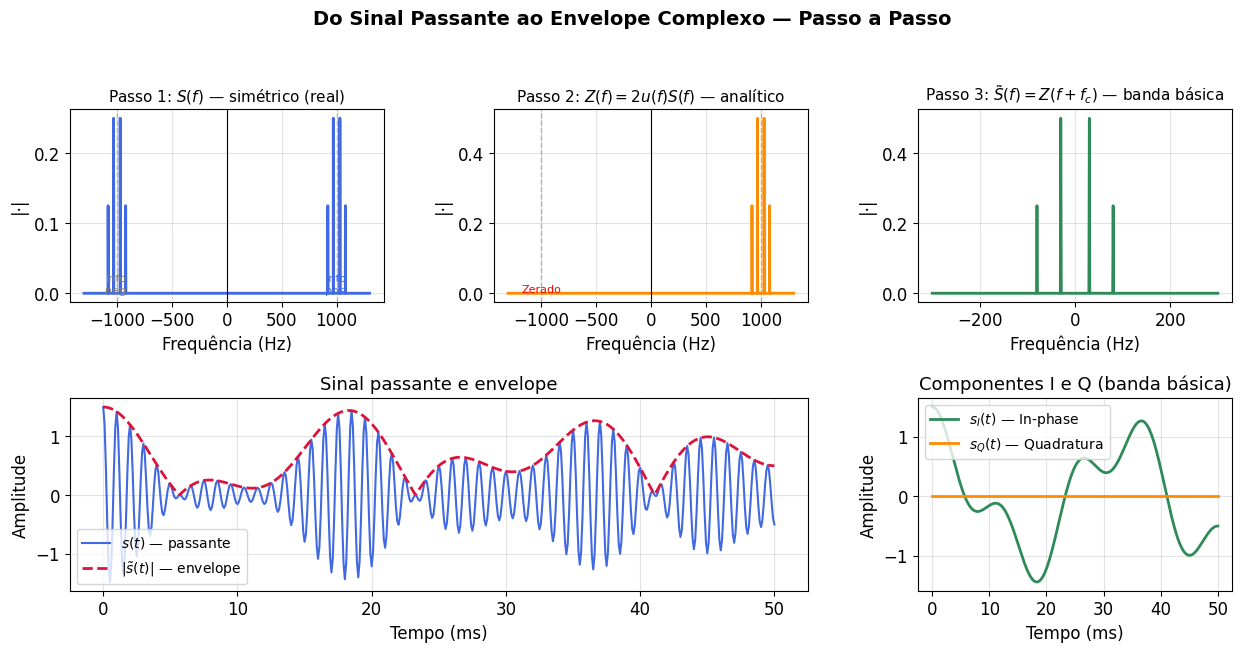

In [3]:
fs  = 10000
T   = 1.0
t   = np.arange(0, T, 1/fs)
N   = len(t)
fc  = 1000.0
W   = 100.0

# Sinal de mensagem simples
m_t = np.cos(2*np.pi*30*t) + 0.5*np.cos(2*np.pi*80*t)
s_t = m_t * np.cos(2*np.pi*fc*t)  # AM-DSB-SC

# Passo 1: espectro do sinal passante
f, S = espectro(s_t, fs)
df   = f[1]-f[0]

# Passo 2: sinal analítico — zerar frequências negativas, dobrar as positivas
S_raw = fftshift(fft(s_t)) / fs  # espectro não centrado pelo fftshift já feito
Z_spec = S.copy()
Z_spec[f < 0]  = 0
Z_spec[f == 0] = Z_spec[f == 0] * 0.5  # DC não duplicado
Z_spec[f > 0] *= 2

# Passo 3: deslocar de -fc para banda básica
f_shift = f + fc  # frequências deslocadas
# Interpolamos o espectro deslocado numa grade regular centrada em 0
# (equivalente a multiplicar z(t) por e^{-j2πfc·t})
z_t = ifft(fftshift(Z_spec) * fs)  # sinal analítico no tempo
envelope_t = z_t * np.exp(-1j*2*np.pi*fc*t)  # envelope complexo
f_env, ENV = espectro(envelope_t, fs)

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ---- Linha superior: espectros dos 3 passos ----
mask_s   = (np.abs(f) <= fc + 3*W)
mask_env = (np.abs(f_env) <= 3*W)

labels_passos = [
    ('Passo 1: $S(f)$ — simétrico (real)', f, np.abs(S), mask_s, 'royalblue'),
    ('Passo 2: $Z(f) = 2u(f)S(f)$ — analítico', f, np.abs(Z_spec), mask_s, 'darkorange'),
    ('Passo 3: $\\tilde{S}(f) = Z(f+f_c)$ — banda básica', f_env, np.abs(ENV), mask_env, 'seagreen'),
]

for col, (titulo, f_ax, spec, mask, cor) in enumerate(labels_passos):
    ax = fig.add_subplot(gs[0, col])
    ax.fill_between(f_ax[mask], spec[mask], alpha=0.25, color=cor)
    ax.plot(f_ax[mask], spec[mask], color=cor, lw=2)
    if col < 2:
        ax.axvline(0,  color='k', lw=0.8, ls='-')
        ax.axvline(-fc, color='gray', lw=1, ls='--', alpha=0.5)
        ax.axvline( fc, color='gray', lw=1, ls='--', alpha=0.5)
        if col == 0:
            ax.annotate('Info\nneg.', (-fc, spec[np.argmin(np.abs(f_ax+fc))]), fontsize=8,
                        color='gray', ha='center')
            ax.annotate('Info\npos.', (fc, spec[np.argmin(np.abs(f_ax-fc))]), fontsize=8,
                        color='royalblue', ha='center')
        elif col == 1:
            ax.annotate('Zerado', (-fc, 0.001), fontsize=8, color='red', ha='center')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('|·|')

# ---- Linha do meio: sinais no tempo ----
ax_s  = fig.add_subplot(gs[1, :2])
ax_env = fig.add_subplot(gs[1, 2])

mask_t = t <= 0.05
ax_s.plot(t[mask_t]*1000, s_t[mask_t], 'royalblue', lw=1.5, label='$s(t)$ — passante')
ax_s.plot(t[mask_t]*1000, np.abs(envelope_t[mask_t]), 'crimson', lw=2, ls='--', label='$|\\tilde{s}(t)|$ — envelope')
ax_s.set_xlabel('Tempo (ms)')
ax_s.set_ylabel('Amplitude')
ax_s.set_title('Sinal passante e envelope')
ax_s.legend(fontsize=10)

ax_env.plot(t[mask_t]*1000, np.real(envelope_t[mask_t]), 'seagreen',  lw=2, label='$s_I(t)$ — In-phase')
ax_env.plot(t[mask_t]*1000, np.imag(envelope_t[mask_t]), 'darkorange', lw=2, label='$s_Q(t)$ — Quadratura')
ax_env.set_xlabel('Tempo (ms)')
ax_env.set_ylabel('Amplitude')
ax_env.set_title('Componentes I e Q (banda básica)')
ax_env.legend(fontsize=10)

fig.suptitle('Do Sinal Passante ao Envelope Complexo — Passo a Passo', fontsize=14, fontweight='bold')
plt.show()

---
## 3. Transformada de Hilbert — Visualização

A **Transformada de Hilbert** $\hat{s}(t)$ é uma defasagem de $90°$ em cada componente:

$$\hat{S}(f) = -j\,\text{sgn}(f)\cdot S(f)$$

Efeito:
- $\cos(2\pi f_0 t) \xrightarrow{\mathcal{H}} \sin(2\pi f_0 t)$
- $\sin(2\pi f_0 t) \xrightarrow{\mathcal{H}} -\cos(2\pi f_0 t)$
- **Não altera a magnitude espectral!**

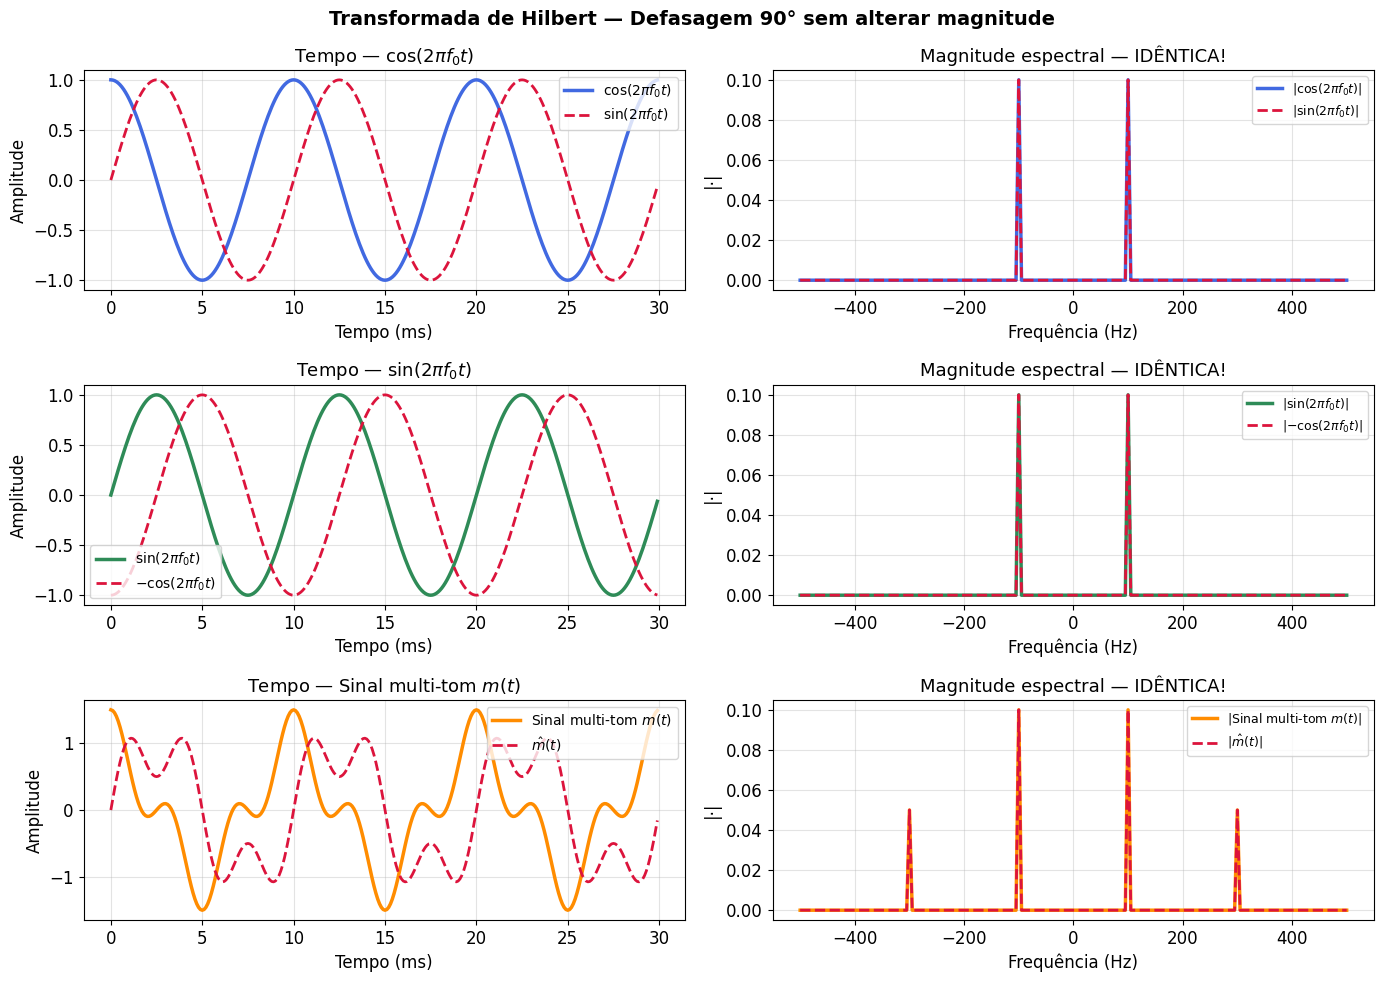

Verificação: cos → sin, erro máximo = 1.73e-14 (deve ser ≈ 0)


In [4]:
fs  = 10000
T   = 0.2
t   = np.arange(0, T, 1/fs)
f0  = 100.0

sinais_hilbert = [
    (np.cos(2*np.pi*f0*t),    r'$\cos(2\pi f_0 t)$',    r'$\sin(2\pi f_0 t)$',   'royalblue'),
    (np.sin(2*np.pi*f0*t),    r'$\sin(2\pi f_0 t)$',    r'$-\cos(2\pi f_0 t)$',  'seagreen'),
    # sinal de mensagem com múltiplas frequências
    (np.cos(2*np.pi*f0*t) + 0.5*np.cos(2*np.pi*3*f0*t),
     r'Sinal multi-tom $m(t)$', r'$\hat{m}(t)$', 'darkorange'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for row, (x, label_x, label_hx, cor) in enumerate(sinais_hilbert):
    # Transformada de Hilbert
    z  = sig.hilbert(x)   # sinal analítico = x + j*hilbert(x)
    hx = np.imag(z)       # parte imaginária = transformada de Hilbert

    # Domínio do tempo
    mask_t = t <= 3/f0
    axes[row, 0].plot(t[mask_t]*1000, x[mask_t],  color=cor,    lw=2.5, label=label_x)
    axes[row, 0].plot(t[mask_t]*1000, hx[mask_t], color='crimson', lw=2, ls='--', label=label_hx)
    axes[row, 0].set_xlabel('Tempo (ms)')
    axes[row, 0].set_ylabel('Amplitude')
    axes[row, 0].set_title(f'Tempo — {label_x}')
    axes[row, 0].legend(fontsize=10)

    # Espectro de magnitude — deve ser idêntico!
    f_ax, X_spec  = espectro(x, fs)
    f_ax, HX_spec = espectro(hx, fs)
    mask_f = np.abs(f_ax) <= 5*f0
    axes[row, 1].plot(f_ax[mask_f], np.abs(X_spec[mask_f]),  color=cor,    lw=2.5, label=f'|{label_x}|')
    axes[row, 1].plot(f_ax[mask_f], np.abs(HX_spec[mask_f]), color='crimson', lw=2, ls='--', label=f'|{label_hx}|')
    axes[row, 1].set_xlabel('Frequência (Hz)')
    axes[row, 1].set_ylabel('|·|')
    axes[row, 1].set_title('Magnitude espectral — IDÊNTICA!')
    axes[row, 1].legend(fontsize=9)

fig.suptitle('Transformada de Hilbert — Defasagem 90° sem alterar magnitude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verificação numérica
x_test  = np.cos(2*np.pi*f0*t)
hx_test = np.imag(sig.hilbert(x_test))
erro = np.max(np.abs(hx_test - np.sin(2*np.pi*f0*t)))
print(f"Verificação: cos → sin, erro máximo = {erro:.2e} (deve ser ≈ 0)")

---
## 4. Componentes I/Q e Envelope Complexo

O sinal analítico $z(t) = s(t) + j\hat{s}(t)$ permite extrair o **envelope complexo**:

$$\tilde{s}(t) = z(t)\,e^{-j2\pi f_c t} = s_I(t) + j\,s_Q(t)$$

E o sinal passante é reconstruído por:

$$s(t) = s_I(t)\cos(2\pi f_c t) - s_Q(t)\sin(2\pi f_c t)$$

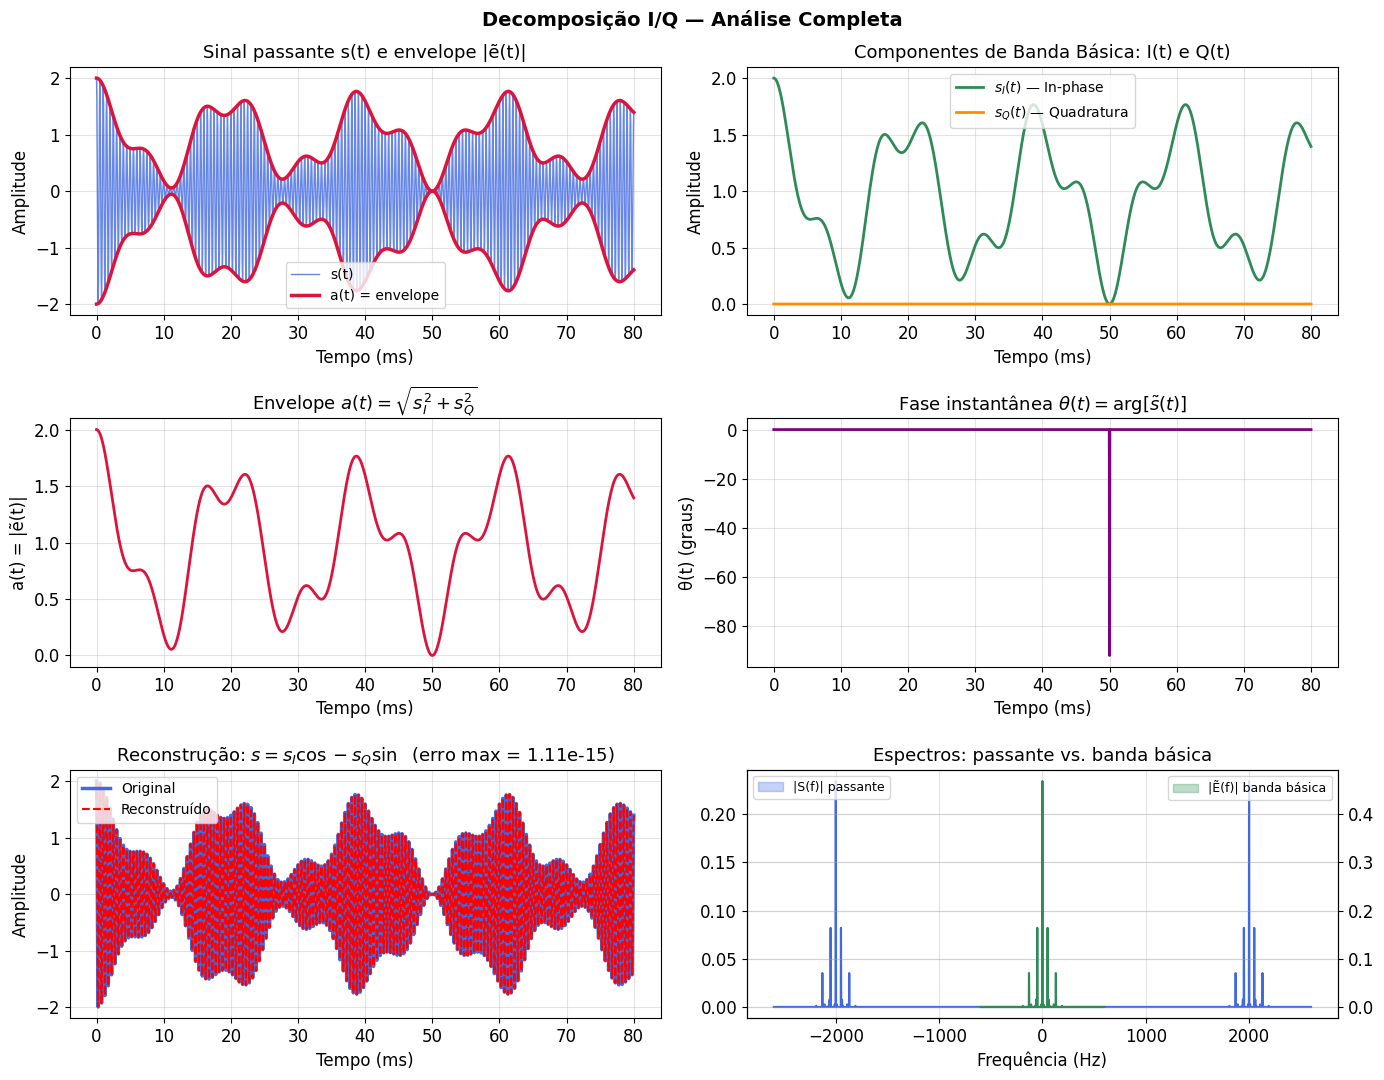

In [5]:
fs  = 20000
T   = 0.5
t   = np.arange(0, T, 1/fs)
fc  = 2000.0

# Sinal de mensagem AM com variação lenta
Am  = 1.0 + 0.7*np.cos(2*np.pi*50*t) + 0.3*np.cos(2*np.pi*130*t)
phi = 0.5*np.sin(2*np.pi*30*t)   # pequena variação de fase
m_t = Am * np.cos(phi)            # mensagem com amplitude e fase variáveis

# Sinal passante
s_t = m_t * np.cos(2*np.pi*fc*t)

# Sinal analítico e envelope complexo
z_t       = sig.hilbert(s_t)
envelope  = z_t * np.exp(-1j*2*np.pi*fc*t)
sI        = np.real(envelope)
sQ        = np.imag(envelope)
a_t       = np.abs(envelope)      # amplitude do envelope
theta_t   = np.angle(envelope)    # fase instantânea

# Reconstrução
s_recon = sI * np.cos(2*np.pi*fc*t) - sQ * np.sin(2*np.pi*fc*t)

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
mask_t = t <= 0.08

# Sinal passante
axes[0,0].plot(t[mask_t]*1000, s_t[mask_t], 'royalblue', lw=1, alpha=0.8, label='s(t)')
axes[0,0].plot(t[mask_t]*1000,  a_t[mask_t], 'crimson', lw=2.5, label='a(t) = envelope')
axes[0,0].plot(t[mask_t]*1000, -a_t[mask_t], 'crimson', lw=2.5)
axes[0,0].set_xlabel('Tempo (ms)'); axes[0,0].set_ylabel('Amplitude')
axes[0,0].set_title('Sinal passante s(t) e envelope |ẽ(t)|')
axes[0,0].legend(fontsize=10)

# Componentes I e Q
axes[0,1].plot(t[mask_t]*1000, sI[mask_t], 'seagreen',   lw=2, label='$s_I(t)$ — In-phase')
axes[0,1].plot(t[mask_t]*1000, sQ[mask_t], 'darkorange', lw=2, label='$s_Q(t)$ — Quadratura')
axes[0,1].set_xlabel('Tempo (ms)'); axes[0,1].set_ylabel('Amplitude')
axes[0,1].set_title('Componentes de Banda Básica: I(t) e Q(t)')
axes[0,1].legend(fontsize=10)

# Envelope e fase
axes[1,0].plot(t[mask_t]*1000, a_t[mask_t], 'crimson', lw=2)
axes[1,0].set_xlabel('Tempo (ms)'); axes[1,0].set_ylabel('a(t) = |ẽ(t)|')
axes[1,0].set_title('Envelope $a(t) = \\sqrt{s_I^2 + s_Q^2}$')

axes[1,1].plot(t[mask_t]*1000, np.degrees(theta_t[mask_t]), 'purple', lw=2)
axes[1,1].set_xlabel('Tempo (ms)'); axes[1,1].set_ylabel('θ(t) (graus)')
axes[1,1].set_title('Fase instantânea $\\theta(t) = \\arg[\\tilde{s}(t)]$')

# Verificação de reconstrução
erro = np.max(np.abs(s_recon - s_t))
axes[2,0].plot(t[mask_t]*1000, s_t[mask_t], 'royalblue', lw=2.5, label='Original')
axes[2,0].plot(t[mask_t]*1000, s_recon[mask_t], 'r--', lw=1.5, label='Reconstruído')
axes[2,0].set_xlabel('Tempo (ms)'); axes[2,0].set_ylabel('Amplitude')
axes[2,0].set_title(f'Reconstrução: $s = s_I\\cos - s_Q\\sin$  (erro max = {erro:.2e})')
axes[2,0].legend(fontsize=10)

# Espectros
f_ax, S_spec  = espectro(s_t, fs)
f_env, E_spec = espectro(envelope, fs)
mask_pb = (np.abs(f_ax) <= fc+3*200) & (np.abs(f_ax) >= fc-3*200)
mask_bb = np.abs(f_env) <= 3*200

axes[2,1].fill_between(f_ax[mask_pb], np.abs(S_spec[mask_pb]), alpha=0.3, color='royalblue', label='|S(f)| passante')
axes[2,1].plot(f_ax[mask_pb], np.abs(S_spec[mask_pb]), 'royalblue', lw=1.5)
ax2 = axes[2,1].twinx()
ax2.fill_between(f_env[mask_bb], np.abs(E_spec[mask_bb]), alpha=0.3, color='seagreen', label='|Ẽ(f)| banda básica')
ax2.plot(f_env[mask_bb], np.abs(E_spec[mask_bb]), 'seagreen', lw=1.5)
axes[2,1].set_xlabel('Frequência (Hz)')
axes[2,1].set_title('Espectros: passante vs. banda básica')
axes[2,1].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

fig.suptitle('Decomposição I/Q — Análise Completa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Trajetória I/Q no Plano Complexo (Constelação)

O envelope complexo $\tilde{s}(t) = s_I(t) + j\,s_Q(t)$ pode ser visualizado como um **vetor girando** no plano I/Q.  
Para diferentes tipos de modulação, a trajetória tem formas características:

- **AM**: vetor oscila ao longo do eixo I
- **FM**: vetor tem magnitude constante, fase variável (círculo)
- **QPSK**: salta entre 4 pontos no círculo

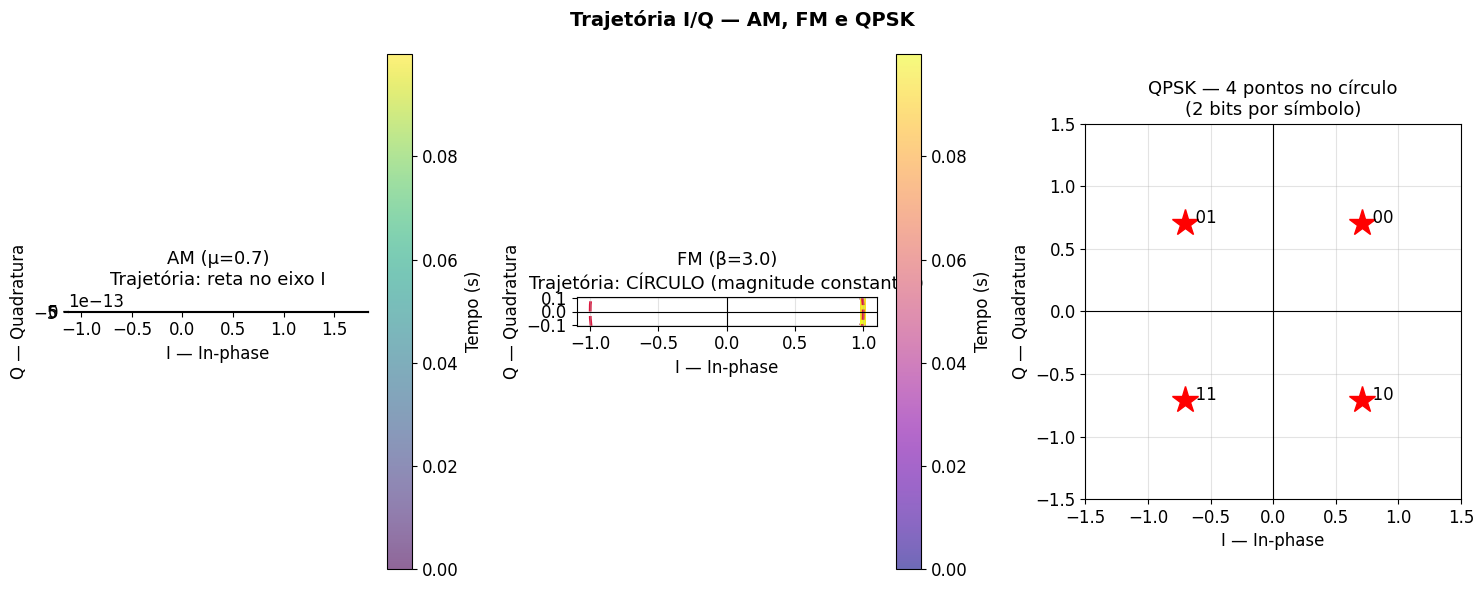

AM:   magnitude variável, fase ≈ constante → trajetória no eixo I
FM:   magnitude CONSTANTE, fase variável → trajetória circular
QPSK: pontos discretos → informação codificada na FASE


In [6]:
fs  = 40000
T   = 0.1
t   = np.arange(0, T, 1/fs)
fc  = 5000.0
fm  = 200.0    # frequência da mensagem
Ac  = 1.0
mu  = 0.7      # índice de modulação AM
beta = 3.0     # índice de modulação FM

# AM convencional
m_am = np.cos(2*np.pi*fm*t)
s_am = Ac * (1 + mu*m_am) * np.cos(2*np.pi*fc*t)
env_am = sig.hilbert(s_am) * np.exp(-1j*2*np.pi*fc*t)

# FM
fase_fm = 2*np.pi*beta/fm * np.sin(2*np.pi*fm*t)  # integral de cos = sin/fm
s_fm  = Ac * np.cos(2*np.pi*fc*t + fase_fm)
env_fm = sig.hilbert(s_fm) * np.exp(-1j*2*np.pi*fc*t)

# QPSK (4 símbolos)
n_sim = 20
T_sim = T / n_sim
bits  = np.random.RandomState(42).randint(0, 4, n_sim)
phases_qpsk = np.pi/4 + bits * np.pi/2  # 45°, 135°, 225°, 315°
s_I_qpsk = np.repeat(np.cos(phases_qpsk), int(T_sim*fs))
s_Q_qpsk = np.repeat(np.sin(phases_qpsk), int(T_sim*fs))

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# AM — constelação
I_am = np.real(env_am)
Q_am = np.imag(env_am)
sc = axes[0].scatter(I_am[::5], Q_am[::5], c=t[::5], cmap='viridis', s=8, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='Tempo (s)')
axes[0].set_xlabel('I — In-phase')
axes[0].set_ylabel('Q — Quadratura')
axes[0].set_title(f'AM (μ={mu})\nTrajetória: reta no eixo I')
axes[0].axhline(0, color='k', lw=0.8); axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_aspect('equal')
circle = plt.Circle((0,0), Ac, fill=False, color='gray', ls='--', lw=1)
axes[0].add_patch(circle)

# FM — constelação
I_fm = np.real(env_fm)
Q_fm = np.imag(env_fm)
sc2 = axes[1].scatter(I_fm[::5], Q_fm[::5], c=t[::5], cmap='plasma', s=8, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='Tempo (s)')
axes[1].set_xlabel('I — In-phase')
axes[1].set_ylabel('Q — Quadratura')
axes[1].set_title(f'FM (β={beta})\nTrajetória: CÍRCULO (magnitude constante!)')
axes[1].axhline(0, color='k', lw=0.8); axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_aspect('equal')
circle2 = plt.Circle((0,0), Ac, fill=False, color='crimson', ls='--', lw=2)
axes[1].add_patch(circle2)

# QPSK — constelação
axes[2].scatter(s_I_qpsk[::10], s_Q_qpsk[::10], color='royalblue', s=15, alpha=0.4, label='Trajetória')
# Pontos dos símbolos
for b in range(4):
    ph = np.pi/4 + b*np.pi/2
    axes[2].plot(np.cos(ph), np.sin(ph), 'r*', markersize=20)
    axes[2].annotate(f'  {["00","01","11","10"][b]}', (np.cos(ph), np.sin(ph)), fontsize=12)
axes[2].set_xlabel('I — In-phase')
axes[2].set_ylabel('Q — Quadratura')
axes[2].set_title('QPSK — 4 pontos no círculo\n(2 bits por símbolo)')
axes[2].axhline(0, color='k', lw=0.8); axes[2].axvline(0, color='k', lw=0.8)
axes[2].set_aspect('equal')
axes[2].set_xlim([-1.5, 1.5]); axes[2].set_ylim([-1.5, 1.5])

fig.suptitle('Trajetória I/Q — AM, FM e QPSK', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("AM:   magnitude variável, fase ≈ constante → trajetória no eixo I")
print("FM:   magnitude CONSTANTE, fase variável → trajetória circular")
print("QPSK: pontos discretos → informação codificada na FASE")

---
## 6. Envelope e Fase/Frequência Instantânea

Do sinal analítico $z(t) = s(t) + j\hat{s}(t)$:

$$a(t) = |z(t)| = \sqrt{s^2(t) + \hat{s}^2(t)} \quad \text{(envelope)}$$
$$\theta(t) = \arg[z(t)] \quad \text{(fase instantânea)}$$
$$f_i(t) = \frac{1}{2\pi}\frac{d\theta}{dt} \quad \text{(frequência instantânea)}$$

Comparamos AM (amplitude varia) vs. FM (frequência varia).

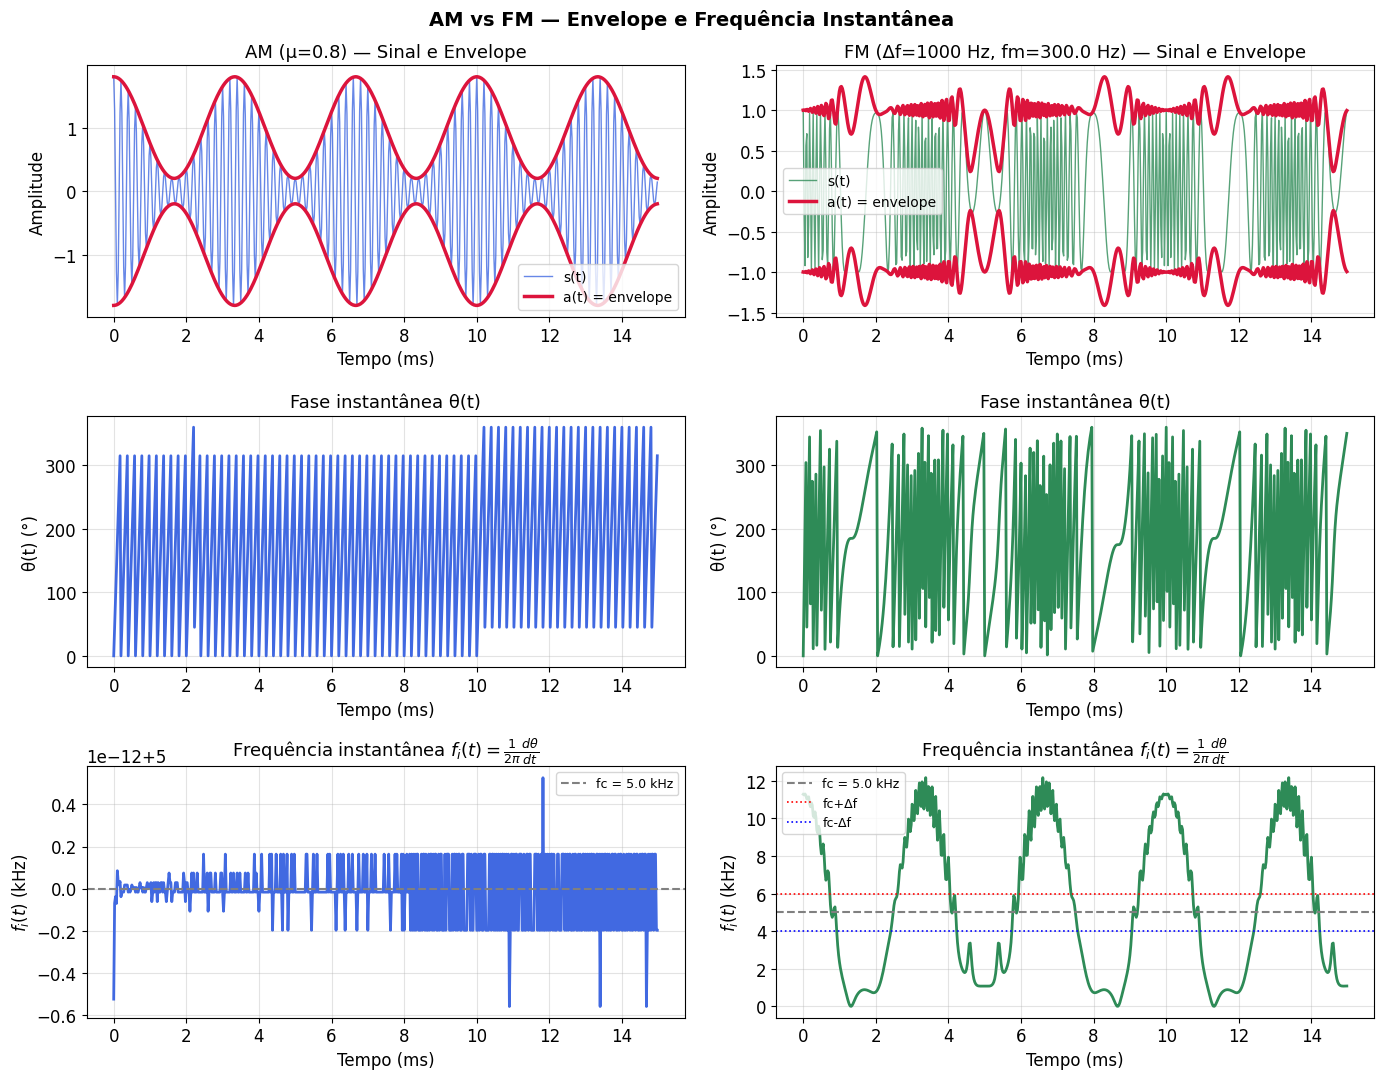

AM:  Envelope varia com m(t), frequência instantânea ≈ constante em 5000.0 Hz
FM:  Envelope constante = 1.0, frequência oscila entre 4000.0 e 6000.0 Hz


In [7]:
fs    = 40000
T     = 0.05
t     = np.arange(0, T, 1/fs)
fc    = 5000.0
fm    = 300.0
Ac    = 1.0
mu    = 0.8    # índice AM
Delta_f = 1000 # desvio de frequência FM (Hz)

# AM convencional
m_t    = np.cos(2*np.pi*fm*t)
s_am   = Ac*(1 + mu*m_t)*np.cos(2*np.pi*fc*t)
z_am   = sig.hilbert(s_am)
env_am = np.abs(z_am)
fase_am = np.unwrap(np.angle(z_am))
fi_am  = np.diff(fase_am) / (2*np.pi/fs)  # frequência instantânea

# FM
fase_msg = Delta_f/fm * np.sin(2*np.pi*fm*t)  # integral de cos(2πfm·t)
s_fm   = Ac*np.cos(2*np.pi*fc*t + 2*np.pi*fase_msg)
z_fm   = sig.hilbert(s_fm)
env_fm = np.abs(z_fm)
fase_fm_inst = np.unwrap(np.angle(z_fm))
fi_fm  = np.diff(fase_fm_inst) / (2*np.pi/fs)

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
mask_t = t <= 0.015

for col, (s, z, env, fase, fi, titulo, cor) in enumerate([
    (s_am, z_am, env_am, fase_am, fi_am, f'AM (μ={mu})', 'royalblue'),
    (s_fm, z_fm, env_fm, fase_fm_inst, fi_fm, f'FM (Δf={Delta_f} Hz, fm={fm} Hz)', 'seagreen'),
]):
    # Sinal e envelope
    axes[0,col].plot(t[mask_t]*1000, s[mask_t], color=cor, lw=1, alpha=0.8, label='s(t)')
    axes[0,col].plot(t[mask_t]*1000,  env[mask_t], 'crimson', lw=2.5, label='a(t) = envelope')
    axes[0,col].plot(t[mask_t]*1000, -env[mask_t], 'crimson', lw=2.5)
    axes[0,col].set_xlabel('Tempo (ms)')
    axes[0,col].set_ylabel('Amplitude')
    axes[0,col].set_title(f'{titulo} — Sinal e Envelope')
    axes[0,col].legend(fontsize=10)

    # Fase instantânea
    axes[1,col].plot(t[mask_t]*1000, np.degrees(fase[mask_t] % (2*np.pi)), color=cor, lw=2)
    axes[1,col].set_xlabel('Tempo (ms)')
    axes[1,col].set_ylabel('θ(t) (°)')
    axes[1,col].set_title('Fase instantânea θ(t)')

    # Frequência instantânea
    t_fi = t[:-1]
    mask_fi = t_fi <= 0.015
    axes[2,col].plot(t_fi[mask_fi]*1000, fi[mask_fi]/1000, color=cor, lw=2)
    axes[2,col].axhline(fc/1000, color='gray', ls='--', lw=1.5, label=f'fc = {fc/1000} kHz')
    if col == 1:
        axes[2,col].axhline((fc+Delta_f)/1000, color='red', ls=':', lw=1.2, label=f'fc+Δf')
        axes[2,col].axhline((fc-Delta_f)/1000, color='blue', ls=':', lw=1.2, label=f'fc-Δf')
    axes[2,col].set_xlabel('Tempo (ms)')
    axes[2,col].set_ylabel('$f_i(t)$ (kHz)')
    axes[2,col].set_title('Frequência instantânea $f_i(t) = \\frac{1}{2\\pi}\\frac{d\\theta}{dt}$')
    axes[2,col].legend(fontsize=9)

fig.suptitle('AM vs FM — Envelope e Frequência Instantânea', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"AM:  Envelope varia com m(t), frequência instantânea ≈ constante em {fc} Hz")
print(f"FM:  Envelope constante = {Ac}, frequência oscila entre {fc-Delta_f} e {fc+Delta_f} Hz")

---
## 7. Modulador/Demodulador I/Q Completo

O ciclo completo de comunicação em banda básica:

```
m(t) → [Modulador I/Q] → s(t) → [Canal] → r(t) → [Demodulador I/Q] → m_rec(t)
```

O demodulador I/Q faz o inverso: multiplica por $\cos$ e $\sin$, depois filtra.

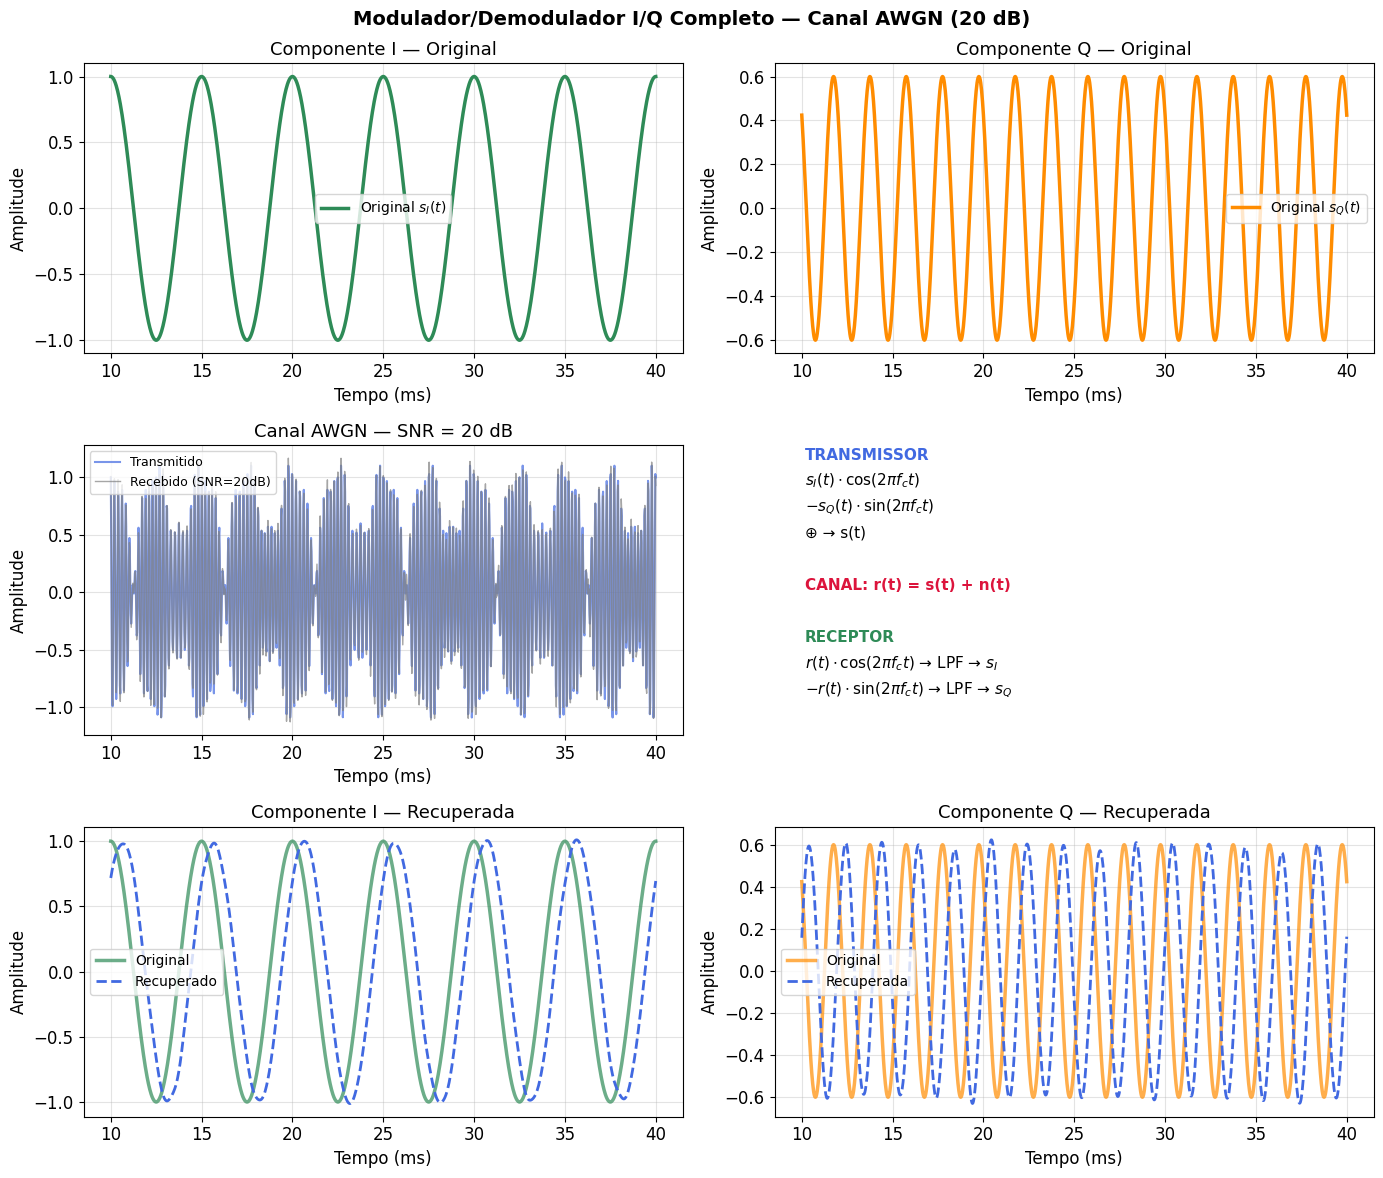

Canal:  SNR entrada = 20 dB
Saída:  SNR(I) ≈ -3.5 dB  |  SNR(Q) ≈ -4.8 dB


In [8]:
fs   = 40000
T    = 0.5
t    = np.arange(0, T, 1/fs)
fc   = 5000.0
fm1  = 200.0
fm2  = 500.0
SNR_dB = 20   # dB de SNR no canal

# ============ MODULADOR ============
# Mensagem banda básica (2 tons)
sI_orig = np.cos(2*np.pi*fm1*t)               # componente I
sQ_orig = 0.6*np.cos(2*np.pi*fm2*t + np.pi/4) # componente Q

# Sinal passante
s_tx = sI_orig*np.cos(2*np.pi*fc*t) - sQ_orig*np.sin(2*np.pi*fc*t)

# ============ CANAL (AWGN) ============
Ps    = np.mean(s_tx**2)
SNR   = 10**(SNR_dB/10)
sigma = np.sqrt(Ps / (2*SNR))
rng   = np.random.default_rng(7)
ruido = rng.normal(0, sigma, len(t))
r_t   = s_tx + ruido

# ============ DEMODULADOR ============
# Multiplicar por portadoras locais (sincronizado)
sI_dem_raw = 2 * r_t * np.cos(2*np.pi*fc*t)
sQ_dem_raw = -2 * r_t * np.sin(2*np.pi*fc*t)

# Filtro passa-baixa (remove componente em 2fc)
B_filt = max(fm1, fm2) * 2.5
sos    = sig.butter(8, B_filt, btype='low', fs=fs, output='sos')
sI_rec = sig.sosfilt(sos, sI_dem_raw)
sQ_rec = sig.sosfilt(sos, sQ_dem_raw)

# Métricas
atraso = int(0.002 * fs)  # atraso do filtro
SNR_I = 10*np.log10(np.mean(sI_orig[atraso:]**2) / np.mean((sI_rec[atraso:]-sI_orig[:-atraso or None])**2))
SNR_Q = 10*np.log10(np.mean(sQ_orig[atraso:]**2) / np.mean((sQ_rec[atraso:]-sQ_orig[:-atraso or None])**2))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
mask_t = (t >= 0.01) & (t <= 0.04)

# Mensagem original I
axes[0,0].plot(t[mask_t]*1000, sI_orig[mask_t], 'seagreen', lw=2.5, label='Original $s_I(t)$')
axes[0,0].set_title('Componente I — Original')
axes[0,0].set_xlabel('Tempo (ms)'); axes[0,0].set_ylabel('Amplitude')
axes[0,0].legend(fontsize=10)

# Mensagem original Q
axes[0,1].plot(t[mask_t]*1000, sQ_orig[mask_t], 'darkorange', lw=2.5, label='Original $s_Q(t)$')
axes[0,1].set_title('Componente Q — Original')
axes[0,1].set_xlabel('Tempo (ms)'); axes[0,1].set_ylabel('Amplitude')
axes[0,1].legend(fontsize=10)

# Sinal transmitido + ruidoso
axes[1,0].plot(t[mask_t]*1000, s_tx[mask_t], 'royalblue', lw=1.5, alpha=0.7, label='Transmitido')
axes[1,0].plot(t[mask_t]*1000, r_t[mask_t], 'gray', lw=1, alpha=0.7, label=f'Recebido (SNR={SNR_dB}dB)')
axes[1,0].set_title(f'Canal AWGN — SNR = {SNR_dB} dB')
axes[1,0].set_xlabel('Tempo (ms)'); axes[1,0].set_ylabel('Amplitude')
axes[1,0].legend(fontsize=9)

# Diagrama de blocos simplificado
axes[1,1].axis('off')
blocos = [
    'TRANSMISSOR',
    '$s_I(t) \\cdot \\cos(2\\pi f_c t)$',
    '$-s_Q(t) \\cdot \\sin(2\\pi f_c t)$',
    '⊕ → s(t)',
    '',
    'CANAL: r(t) = s(t) + n(t)',
    '',
    'RECEPTOR',
    '$r(t) \\cdot \\cos(2\\pi f_c t)$ → LPF → $s_I$',
    '$-r(t) \\cdot \\sin(2\\pi f_c t)$ → LPF → $s_Q$',
]
for i, b in enumerate(blocos):
    cor_texto = 'royalblue' if 'TRANS' in b else ('crimson' if 'CANAL' in b else ('seagreen' if 'RECEP' in b else 'black'))
    axes[1,1].text(0.05, 0.95 - i*0.09, b, transform=axes[1,1].transAxes,
                   fontsize=11, color=cor_texto,
                   fontweight='bold' if b in ['TRANSMISSOR','CANAL: r(t) = s(t) + n(t)','RECEPTOR'] else 'normal')

# Recuperado I
axes[2,0].plot(t[mask_t]*1000, sI_orig[mask_t], 'seagreen', lw=2.5, alpha=0.7, label='Original')
axes[2,0].plot(t[mask_t]*1000, sI_rec[mask_t], 'royalblue', lw=2, ls='--', label=f'Recuperado')
axes[2,0].set_title(f'Componente I — Recuperada')
axes[2,0].set_xlabel('Tempo (ms)'); axes[2,0].set_ylabel('Amplitude')
axes[2,0].legend(fontsize=10)

# Recuperado Q
axes[2,1].plot(t[mask_t]*1000, sQ_orig[mask_t], 'darkorange', lw=2.5, alpha=0.7, label='Original')
axes[2,1].plot(t[mask_t]*1000, sQ_rec[mask_t], 'royalblue',  lw=2, ls='--', label=f'Recuperada')
axes[2,1].set_title(f'Componente Q — Recuperada')
axes[2,1].set_xlabel('Tempo (ms)'); axes[2,1].set_ylabel('Amplitude')
axes[2,1].legend(fontsize=10)

fig.suptitle(f'Modulador/Demodulador I/Q Completo — Canal AWGN ({SNR_dB} dB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Canal:  SNR entrada = {SNR_dB} dB")
print(f"Saída:  SNR(I) ≈ {SNR_I:.1f} dB  |  SNR(Q) ≈ {SNR_Q:.1f} dB")

---
## Resumo — Seção 3.10

| Passo | Frequência | Tempo |
|---|---|---|
| 1. Sinal passante | $S(f)$ em $\pm f_c$ | $s(t)$ real |
| 2. Sinal analítico | $Z(f) = 2S(f)\,u(f)$ | $z(t) = s(t) + j\hat{s}(t)$ |
| 3. Envelope complexo | $\tilde{S}(f) = Z(f+f_c)$ | $\tilde{s}(t) = z(t)\,e^{-j2\pi f_c t}$ |
| 4. Componentes I/Q | banda básica complexa | $\tilde{s}(t) = s_I(t) + j\,s_Q(t)$ |
| 5. Reconstrução | $S(f)$ recuperado | $s(t) = s_I\cos - s_Q\sin$ |

**Conexões importantes:**
- **AM** → magnitude de $\tilde{s}$ varia, fase constante → trajetória no eixo I
- **FM** → magnitude de $\tilde{s}$ constante, fase varia → trajetória circular  
- **QAM/QPSK** → ambos I e Q carregam informação → constelação 2D
- **Hilbert** → ponte entre sinal real e analítico, define unicidade da representação
